# ABR/OAE Preprocessing Pipeline

The processing logic lives in `src/abr_oae_preprocessing`. This notebook is the main run flow: configure paths, run EARNDB, inspect one average, run EARH, inspect one average, save outputs and compare against the published EARNDB averages.


In [68]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from abr_oae_preprocessing import (
    PreprocessConfig,
    build_oae_gain_overrides,
    collect_earh_paths,
    collect_earndb_paths,
    compare_published_earndb_averages,
    preprocess_dataset,
    save_preprocessed_results,
)
from abr_oae_preprocessing.outputs import plot_condition_average


## Paths and Configuration


In [69]:
EARNDB_ROOT = PROJECT_ROOT / "data" / "earndb" / "raw"
EARH_ROOT = PROJECT_ROOT / "data" / "earh"
EARNDB_AVERAGE_ROOT = PROJECT_ROOT / "data" / "earndb" / "average"
OUT_ROOT = PROJECT_ROOT / "data" / "preprocessed"

OUT_ROOT.mkdir(parents=True, exist_ok=True)

print("EARNDB raw:", EARNDB_ROOT, EARNDB_ROOT.exists())
print("EARH raw:", EARH_ROOT, EARH_ROOT.exists())
print("EARNDB published averages:", EARNDB_AVERAGE_ROOT, EARNDB_AVERAGE_ROOT.exists())
print("Output:", OUT_ROOT)


EARNDB raw: /Users/matthias/Downloads/abr-oae-hearing-analysis/data/earndb/raw True
EARH raw: /Users/matthias/Downloads/abr-oae-hearing-analysis/data/earh True
EARNDB published averages: /Users/matthias/Downloads/abr-oae-hearing-analysis/data/earndb/average True
Output: /Users/matthias/Downloads/abr-oae-hearing-analysis/data/preprocessed


In [70]:
COMMON_CONFIG = dict(
    epoch_ms=41.5,
    filter_abr=True,
    abr_low_hz=60.0,
    abr_high_hz=3000.0,
    average_mode="block_weighted",
    split_within_each_record=True,
    block_size_trials=75,
    artifact_policy_by_dataset={"earndb": "threshold_uv", "earh": "threshold_uv"},
    artifact_threshold_uv=50.0,
)


In [71]:
def preview_average(results, preferred_key=None):
    if preferred_key in results:
        key = preferred_key
    else:
        key = next(iter(results))

    fig = plot_condition_average(results[key], show=True)
    return key, fig


## EARNDB Preprocessing


In [72]:
earndb_paths = collect_earndb_paths(EARNDB_ROOT, subject=None, exclude_x=True)
print("EARNDB paths:", len(earndb_paths))

earndb_gain_overrides, earndb_gain_report = build_oae_gain_overrides(
    earndb_paths,
    dataset="earndb",
    min_valid_gain=1.0,
)

(OUT_ROOT / "earndb").mkdir(parents=True, exist_ok=True)
earndb_gain_report.to_csv(OUT_ROOT / "earndb" / "oae_gain_corrections.csv", index=False)
print("OAE gain corrections:", len(earndb_gain_report))
earndb_gain_report.head()


EARNDB paths: 1995
OAE gain corrections: 993


,condition,record,status,channel,old_gain,new_gain,valid_gains
0,"(earndb, N1, 1000, 100)",N1_evoked_raw_100_F1_R2,corrected,1,0.01,2.147484e+10,"[21474836480.0, 21474836480.0]"
1,"(earndb, N1, 4000, 100)",N1_evoked_raw_100_F4_R1,corrected,1,0.01,2.147484e+10,"[21474836480.0, 21474836480.0, 21474836480.0, ..."
2,"(earndb, N1, 4000, 100)",N1_evoked_raw_100_F4_R5,corrected,1,0.01,2.147484e+10,"[21474836480.0, 21474836480.0, 21474836480.0, ..."
3,"(earndb, N1, 1000, 10)",N1_evoked_raw_10_F1_R1,corrected,1,0.01,2.147484e+10,"[21474836480.0, 21474836480.0, 21474836480.0, ..."
4,"(earndb, N1, 1000, 10)",N1_evoked_raw_10_F1_R3,corrected,1,0.01,2.147484e+10,"[21474836480.0, 21474836480.0, 21474836480.0, ..."


In [73]:
cfg_earndb = PreprocessConfig(
    **COMMON_CONFIG,
    correct_oae_gain=True,
    gain_overrides=earndb_gain_overrides,
)

earndb_results = preprocess_dataset(earndb_paths, dataset="earndb", cfg=cfg_earndb)
print("EARNDB conditions:", len(earndb_results))


EARNDB conditions: 228


### EARNDB Average Preview


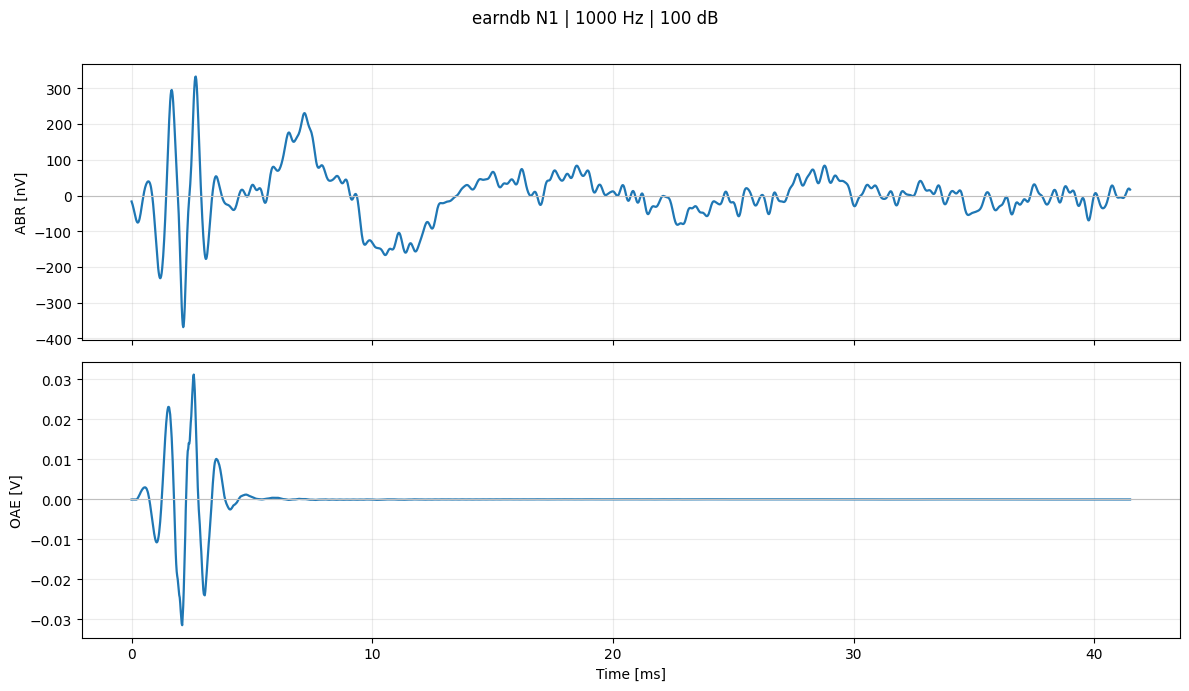

('earndb', 'N1', 1000, 100)

In [74]:
earndb_preview_key, _ = preview_average(
    earndb_results,
    preferred_key=("earndb", "N1", 1000, 100),
)
earndb_preview_key


In [75]:
earndb_metadata = save_preprocessed_results(
    earndb_results,
    out_root=OUT_ROOT,
    dataset_name="earndb",
)
earndb_metadata.head()


Saved 228 conditions to /Users/matthias/Downloads/abr-oae-hearing-analysis/data/preprocessed/earndb
Metadata: /Users/matthias/Downloads/abr-oae-hearing-analysis/data/preprocessed/earndb/metadata.csv


,dataset,subject,frequency_hz,level_db_pespl,fs,epoch_ms,n_epoch_samples,n_records,records,average_mode,...,abr_B_n_blocks,abr_all_n_trials,abr_all_n_blocks,oae_A_n_trials,oae_A_n_blocks,oae_B_n_trials,oae_B_n_blocks,oae_all_n_trials,oae_all_n_blocks,record_metas_json
0,earndb,N1,1000,10,48000.0,41.5,1992,8,"[""N1_evoked_raw_10_F1_R1"", ""N1_evoked_raw_10_F...",block_weighted,...,55,7855,110,4000,56,4000,56,8000,112,"[{""dataset"": ""earndb"", ""subject"": ""N1"", ""frequ..."
1,earndb,N1,1000,15,48000.0,41.5,1992,6,"[""N1_evoked_raw_15_F1_R1"", ""N1_evoked_raw_15_F...",block_weighted,...,42,5978,84,3000,42,3000,42,6000,84,"[{""dataset"": ""earndb"", ""subject"": ""N1"", ""frequ..."
2,earndb,N1,1000,20,48000.0,41.5,1992,2,"[""N1_evoked_raw_20_F1_R2"", ""N1_evoked_raw_20_F...",block_weighted,...,14,1884,26,1000,14,1000,14,2000,28,"[{""dataset"": ""earndb"", ""subject"": ""N1"", ""frequ..."
3,earndb,N1,1000,25,48000.0,41.5,1992,8,"[""N1_evoked_raw_25_F1_R1"", ""N1_evoked_raw_25_F...",block_weighted,...,54,7571,106,4000,56,4000,56,8000,112,"[{""dataset"": ""earndb"", ""subject"": ""N1"", ""frequ..."
4,earndb,N1,1000,30,48000.0,41.5,1992,7,"[""N1_evoked_raw_30_F1_R1"", ""N1_evoked_raw_30_F...",block_weighted,...,49,6997,98,3500,49,3500,49,7000,98,"[{""dataset"": ""earndb"", ""subject"": ""N1"", ""frequ..."


## EARH Preprocessing


In [76]:
earh_paths = collect_earh_paths(EARH_ROOT, subject=None)
print("EARH paths:", len(earh_paths))

cfg_earh = PreprocessConfig(
    **COMMON_CONFIG,
    mad_k=3.0,
    correct_oae_gain=False,
    gain_overrides={},
)

earh_results = preprocess_dataset(earh_paths, dataset="earh", cfg=cfg_earh)
print("EARH conditions:", len(earh_results))


EARH paths: 577
EARH conditions: 144


### EARH Average Preview


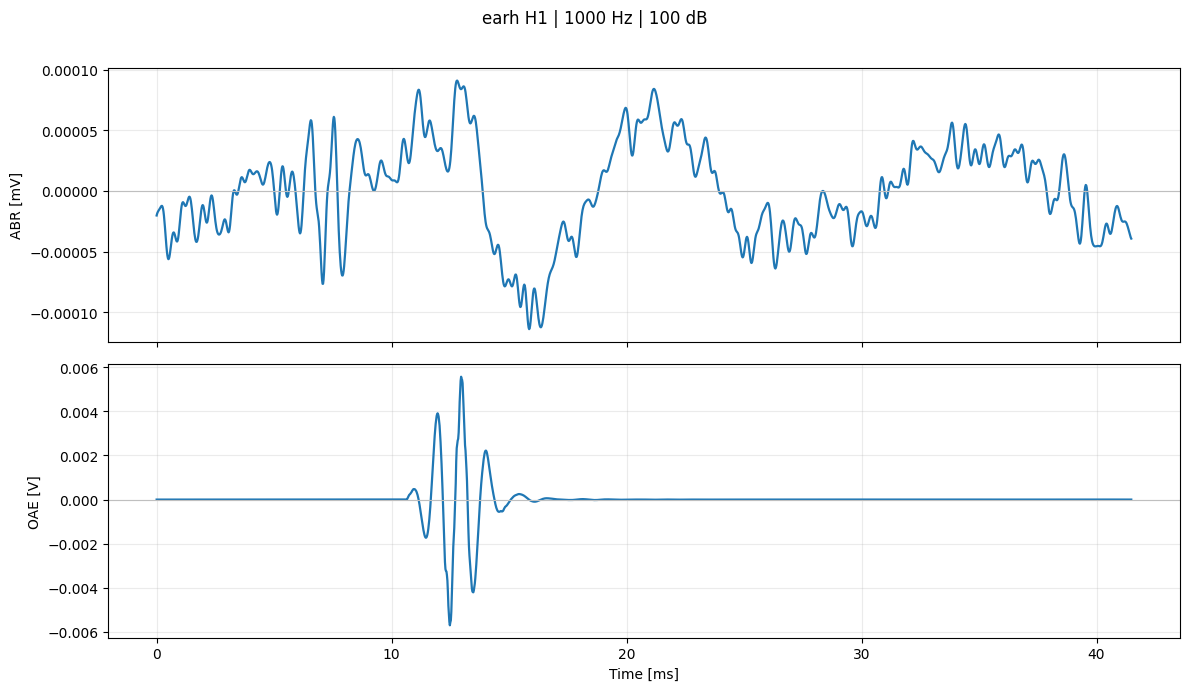

('earh', 'H1', 1000, 100)

In [77]:
earh_preview_key, _ = preview_average(
    earh_results,
    preferred_key=("earh", "H1", 1000, 100),
)
earh_preview_key


In [78]:
earh_metadata = save_preprocessed_results(
    earh_results,
    out_root=OUT_ROOT,
    dataset_name="earh",
)
earh_metadata.head()


Saved 144 conditions to /Users/matthias/Downloads/abr-oae-hearing-analysis/data/preprocessed/earh
Metadata: /Users/matthias/Downloads/abr-oae-hearing-analysis/data/preprocessed/earh/metadata.csv


,dataset,subject,frequency_hz,level_db_pespl,fs,epoch_ms,n_epoch_samples,n_records,records,average_mode,...,abr_B_n_blocks,abr_all_n_trials,abr_all_n_blocks,oae_A_n_trials,oae_A_n_blocks,oae_B_n_trials,oae_B_n_blocks,oae_all_n_trials,oae_all_n_blocks,record_metas_json
0,earh,H1,1000,50,48000.0,41.5,1992,4,"[""h1_l_1kHz_50_1"", ""h1_l_1kHz_50_2"", ""h1_l_1kH...",block_weighted,...,28,4034,56,2016,28,2019,28,4035,56,"[{""dataset"": ""earh"", ""subject"": ""H1"", ""ear"": ""..."
1,earh,H1,1000,55,48000.0,41.5,1992,4,"[""h1_l_1kHz_55_1"", ""h1_l_1kHz_55_2"", ""h1_l_1kH...",block_weighted,...,28,4036,56,2016,28,2020,28,4036,56,"[{""dataset"": ""earh"", ""subject"": ""H1"", ""ear"": ""..."
2,earh,H1,1000,60,48000.0,41.5,1992,4,"[""h1_l_1kHz_60_1"", ""h1_l_1kHz_60_2"", ""h1_l_1kH...",block_weighted,...,28,4035,56,2016,28,2019,28,4035,56,"[{""dataset"": ""earh"", ""subject"": ""H1"", ""ear"": ""..."
3,earh,H1,1000,65,48000.0,41.5,1992,4,"[""h1_l_1kHz_65_1"", ""h1_l_1kHz_65_2"", ""h1_l_1kH...",block_weighted,...,28,4036,56,2016,28,2020,28,4036,56,"[{""dataset"": ""earh"", ""subject"": ""H1"", ""ear"": ""..."
4,earh,H1,1000,70,48000.0,41.5,1992,4,"[""h1_l_1kHz_70_1"", ""h1_l_1kHz_70_2"", ""h1_l_1kH...",block_weighted,...,28,4036,56,2016,28,2020,28,4036,56,"[{""dataset"": ""earh"", ""subject"": ""H1"", ""ear"": ""..."


## Published EARNDB Average Comparison


In [79]:
published_average_summary = compare_published_earndb_averages(
    average_root=EARNDB_AVERAGE_ROOT,
    preprocessed_average_root=OUT_ROOT / "earndb" / "averages",
    out_root=OUT_ROOT / "earndb" / "published_average_comparison",
    subject="N1",
    levels=(100, 90, 80, 70, 60, 50, 40, 30, 20, 10),
)

published_average_summary.head()


Saved 160 comparison rows to /Users/matthias/Downloads/abr-oae-hearing-analysis/data/preprocessed/earndb/published_average_comparison


,record,level_db_pespl,frequency_hz,rep,role,source,norm_scale,ptp,rms
1,earndb_N1_1000Hz_10dB,10,1000,1,abr,new_preprocessed_average,6.609337e+01,1.274489e+02,2.149388e+01
0,N1_evoked_ave10_F1_R1,10,1000,1,abr,published_earndb_average,2.382231e+09,4.294967e+09,8.213116e+08
3,earndb_N1_1000Hz_10dB,10,1000,1,oae,new_preprocessed_average,7.406218e-06,1.319684e-05,2.989640e-06
2,N1_evoked_ave10_F1_R1,10,1000,1,oae,published_earndb_average,2.159666e+09,4.294967e+09,8.582864e+08
5,earndb_N1_1000Hz_10dB,10,1000,2,abr,new_preprocessed_average,6.609337e+01,1.274489e+02,2.149388e+01
